# NB02 — Color Extraction & Hue Classification

Pipeline ekstraksi warna dominan per gambar dari `fruit_split/` dan klasifikasi
ke hue range `red_orange` atau `green_yellow`.

**Alur tahapan:**
1. **2A** — Load metadata NB01, inventarisasi `fruit_split/`
2. **2B** — K-Means optimization per kelas (K dari train, dipakai untuk val+test)
3. **2C** — Ekstraksi & filter per gambar (train, val, test)
4. **2D** — Analisis hasil: distribusi hue, rejection analysis
5. **2E** — Ekspor hasil & ringkasan untuk keputusan undersampling

**Input :** `processed/fruit_split/train|val|test/001apple/...`
**Output:** `processed/fruit_filtered/train|val|test/red_orange|green_yellow/`

> Capped undersampling tidak dijalankan otomatis — distribusi hue diekspor dulu,
> keputusan undersampling ada di cell opsional Tahap 2E.


In [1]:
%pip install opencv-python-headless numpy scikit-learn scipy pillow matplotlib seaborn pandas -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import datetime
import json
import random
import shutil
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED: int = 42

RESEARCH_ROOT = Path(r"C:\Colorblind_correction\research")
PROCESSED_DIR = RESEARCH_ROOT / "datasets" / "processed"
SPLIT_DIR     = PROCESSED_DIR / "fruit_split"
FILTERED_DIR  = PROCESSED_DIR / "fruit_filtered"
EXPORTS_DIR   = RESEARCH_ROOT / "notebooks" / "02" / "output"

FILTERED_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

SATURATION_THRESHOLD : float = 0.20   # piksel saturasi < ini diabaikan (background)
DOMINANCE_THRESHOLD  : float = 0.45   # centroid terbesar harus >= 45% piksel valid
IMAGE_RESIZE         : int   = 224    # resize gambar sebelum K-Means (px)
K_SAMPLE_PER_CLASS   : int   = 150    # gambar per kelas untuk K-optimization
K_RANGE              : tuple = (2, 7)
PIXELS_PER_IMAGE     : int   = 500    # subsample piksel per gambar saat K-opt
SILHOUETTE_SUBSAMPLE : int   = 5_000

# hasil derivasi NB00 yaitu >35 n <330 || 65 > n >160 itu digunakan sebagai batas untuk RO MIN dan GY MAX
# RO MAX dan GY MIN tidak mengikuti NB00 karena hue range buah dataset terutama pada orange-yellow itu di antara 35-65
HUE_RED_ORANGE_MAX   = 40
HUE_RED_ORANGE_MIN   = 330
HUE_GREEN_YELLOW_MIN = 50
HUE_GREEN_YELLOW_MAX = 160
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

print("[INIT] Konfigurasi NB02:")
print(f"  SPLIT_DIR            : {SPLIT_DIR}")
print(f"  FILTERED_DIR         : {FILTERED_DIR}")
print(f"  SATURATION_THRESHOLD : {SATURATION_THRESHOLD:.0%}")
print(f"  DOMINANCE_THRESHOLD  : {DOMINANCE_THRESHOLD:.0%}")
print(f"  IMAGE_RESIZE         : {IMAGE_RESIZE}px")
print(f"  K_SAMPLE_PER_CLASS   : {K_SAMPLE_PER_CLASS} gambar")
print(f"  K_RANGE              : {K_RANGE[0]}–{K_RANGE[1]}")
print(f"  HUE red_orange       : h <= {HUE_RED_ORANGE_MAX}° atau h >= {HUE_RED_ORANGE_MIN}°")
print(f"  HUE green_yellow     : {HUE_GREEN_YELLOW_MIN}° < h <= {HUE_GREEN_YELLOW_MAX}°")


[INIT] Konfigurasi NB02:
  SPLIT_DIR            : C:\Colorblind_correction\research\datasets\processed\fruit_split
  FILTERED_DIR         : C:\Colorblind_correction\research\datasets\processed\fruit_filtered
  SATURATION_THRESHOLD : 20%
  DOMINANCE_THRESHOLD  : 45%
  IMAGE_RESIZE         : 224px
  K_SAMPLE_PER_CLASS   : 150 gambar
  K_RANGE              : 2–7
  HUE red_orange       : h <= 40° atau h >= 330°
  HUE green_yellow     : 50° < h <= 160°


## Tahap 2A — Inventarisasi fruit_split/

Load metadata dari NB01 dan scan struktur `fruit_split/` untuk verifikasi.


In [3]:
_NB01_OUTPUT = RESEARCH_ROOT / "notebooks" / "01" / "output"
summary_path = _NB01_OUTPUT / "preparation_summary.json"
with open(summary_path, "r", encoding="utf-8") as f:
    nb01_summary = json.load(f)

kept_classes: list[str] = nb01_summary["classes_kept"]

# Override SPLIT_DIR dari summary NB01 agar path konsisten walau notebook
# dijalankan di komputer berbeda.
SPLIT_DIR = Path(nb01_summary["output_dir"])

print(f"[2A] Kelas yang di-keep dari NB01: {len(kept_classes)}")
print(f"     SPLIT_DIR (dari NB01)        : {SPLIT_DIR}")
print(f"     {kept_classes}")
print()

# Scan fruit_split/ dan hitung gambar per kelas per subset
inventory_rows: list[dict] = []

for subset in ["train", "val", "test"]:
    subset_dir = SPLIT_DIR / subset
    if not subset_dir.exists():
        print(f"  ⚠ Folder tidak ada: {subset_dir}")
        continue
    for class_dir in sorted(subset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        paths = [
            f for f in class_dir.iterdir()
            if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
        ]
        inventory_rows.append({
            "subset"      : subset,
            "folder_name" : class_dir.name,
            "class_name"  : class_dir.name[3:],
            "count"       : len(paths),
        })

df_inventory = pd.DataFrame(inventory_rows)
df_pivot     = df_inventory.pivot(
    index="folder_name", columns="subset", values="count"
).fillna(0).astype(int)
df_pivot["total"] = df_pivot.sum(axis=1)

print("[2A] Inventarisasi fruit_split/:")
print(df_pivot.to_string())
print()
print(f"  Grand total: {df_pivot['total'].sum():,} gambar")


[2A] Kelas yang di-keep dari NB01: 16
     SPLIT_DIR (dari NB01)        : C:\Colorblind_correction\research\datasets\processed\fruit_split
     ['001apple', '002orange', '003pear', '004tomato', '005strawberry', '006banana', '007watermelon', '009peach', '010pomegranate', '011pineapple', '012starfruit', '014lemon', '015pomelo', '016mango', '018hami', '019papaya']



[2A] Inventarisasi fruit_split/:
subset          test  train  val  total
folder_name                            
001apple          41    332   30    403
002orange         47    381   30    458
003pear           43    205   30    278
004tomato         33    357   30    420
005strawberry     46    385   30    461
006banana         35    298   30    363
007watermelon     41    181   30    252
009peach          36    242   30    308
010pomegranate    13    168   29    210
011pineapple      37    152   26    215
012starfruit      40    122   21    183
014lemon          35    110   19    164
015pomelo         41     89   15    145
016mango          32    114   19    165
018hami           31     73   15    119
019papaya         33     40   15     88

  Grand total: 4,232 gambar


## Tahap 2B — K-Means Optimization Per Kelas

K optimal tiap kelas ditentukan dari gambar train (elbow method + silhouette
score), lalu dipakai untuk val dan test kelas yang sama agar konsisten dan
menghindari data leakage.


In [4]:
def load_and_resize(image_path: Path, size: int = IMAGE_RESIZE) -> np.ndarray | None:
    """Load gambar dan resize ke size x size, None jika gagal dibaca."""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)


def get_saturated_pixels(
    img_bgr      : np.ndarray,
    sat_threshold: float = SATURATION_THRESHOLD,
) -> np.ndarray | None:
    """Ekstrak piksel HSV bersaturasi tinggi, buang background netral sebelum K-Means."""
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    img_hsv[:, :, 0] /= 180.0   # H: 0-180 -> 0-1
    img_hsv[:, :, 1] /= 255.0   # S: 0-255 -> 0-1
    img_hsv[:, :, 2] /= 255.0   # V: 0-255 -> 0-1

    pixels = img_hsv.reshape(-1, 3)
    mask   = pixels[:, 1] >= sat_threshold
    valid  = pixels[mask]

    return valid if len(valid) >= 10 else None


def compute_optimal_k(
    train_paths   : list[Path],
    k_range       : tuple = K_RANGE,
    n_samples     : int   = K_SAMPLE_PER_CLASS,
    pixels_per_img: int   = PIXELS_PER_IMAGE,
    silhouette_sub: int   = SILHOUETTE_SUBSAMPLE,
    random_seed   : int   = RANDOM_SEED,
) -> dict:
    """Cari K optimal satu kelas via elbow + silhouette. Hanya dari train (hindari data leakage)."""
    rng     = random.Random(random_seed)
    sampled = rng.sample(train_paths, min(n_samples, len(train_paths)))

    # Kumpulkan piksel dari semua gambar sample
    all_pixels: list[np.ndarray] = []
    for path in sampled:
        img = load_and_resize(path)
        if img is None:
            continue
        valid = get_saturated_pixels(img)
        if valid is None:
            continue
        # Subsample per gambar agar satu gambar tidak mendominasi kumpulan piksel
        idx = np.random.RandomState(random_seed).choice(
            len(valid), min(pixels_per_img, len(valid)), replace=False
        )
        all_pixels.append(valid[idx])

    if not all_pixels:
        return {"optimal_k": 3, "error": "no valid pixels found"}

    pixels     = np.vstack(all_pixels)
    inertias   : list[float] = []
    sil_scores : list[float] = []
    k_values   = list(range(k_range[0], k_range[1] + 1))

    for k in k_values:
        km     = KMeans(n_clusters=k, random_state=random_seed, n_init=10)
        labels = km.fit_predict(pixels)
        inertias.append(float(km.inertia_))

        if len(pixels) > silhouette_sub:
            idx_sil = np.random.RandomState(random_seed).choice(
                len(pixels), silhouette_sub, replace=False
            )
            sil = silhouette_score(pixels[idx_sil], labels[idx_sil])
        else:
            sil = silhouette_score(pixels, labels)
        sil_scores.append(float(sil))

    # Elbow: titik percepatan penurunan inertia terbesar (second derivative)
    if len(inertias) >= 3:
        deltas  = [inertias[i] - inertias[i + 1] for i in range(len(inertias) - 1)]
        accel   = [deltas[i] - deltas[i + 1] for i in range(len(deltas) - 1)]
        elbow_k = k_values[int(np.argmax(accel)) + 1]
    else:
        elbow_k = k_values[int(np.argmax(sil_scores))]

    best_sil_k = k_values[int(np.argmax(sil_scores))]
    # Selisih elbow vs silhouette <=1 -> pakai silhouette; beda jauh -> pakai elbow (lebih konservatif)
    optimal_k = best_sil_k if abs(elbow_k - best_sil_k) <= 1 else elbow_k

    return {
        "optimal_k"        : optimal_k,
        "elbow_k"          : elbow_k,
        "best_sil_k"       : best_sil_k,
        "k_values"         : k_values,
        "inertias"         : inertias,
        "silhouette_scores": sil_scores,
        "n_pixels_used"    : len(pixels),
        "n_samples_used"   : len(sampled),
    }


print("[2B] Fungsi K-optimization siap.")
print(f"  K akan dicari dalam range K={K_RANGE[0]}–{K_RANGE[1]} per kelas")
print(f"  Sample per kelas: {K_SAMPLE_PER_CLASS} gambar train")


[2B] Fungsi K-optimization siap.
  K akan dicari dalam range K=2–7 per kelas
  Sample per kelas: 150 gambar train


In [5]:
print("[TAHAP 2B] Menjalankan K-optimization per kelas...")
print(f"  {'Kelas':<20} {'K opt':>6} {'K elbow':>8} {'K sil':>6} {'Sil score':>10} {'Pixels':>8} {'Samples':>8}")
print(f"  {'-'*20} {'-'*6} {'-'*8} {'-'*6} {'-'*10} {'-'*8} {'-'*8}")

k_results_per_class: dict[str, dict] = {}

for folder_name in kept_classes:
    train_dir = SPLIT_DIR / "train" / folder_name
    if not train_dir.exists():
        print(f"  {folder_name:<20}  ⚠ folder tidak ada")
        continue

    train_paths = [
        f for f in train_dir.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
    ]

    if len(train_paths) < K_RANGE[0] + 1:
        print(f"  {folder_name:<20}  ⚠ terlalu sedikit gambar ({len(train_paths)})")
        k_results_per_class[folder_name] = {"optimal_k": K_RANGE[0], "error": "too few images"}
        continue

    result = compute_optimal_k(train_paths)
    k_results_per_class[folder_name] = result

    if "error" in result:
        print(f"  {folder_name:<20}  ⚠ {result['error']}")
        continue

    best_sil = max(result["silhouette_scores"])
    print(
        f"  {folder_name:<20} {result['optimal_k']:>6} "
        f"{result['elbow_k']:>8} {result['best_sil_k']:>6} "
        f"{best_sil:>10.4f} {result['n_pixels_used']:>8,} "
        f"{result['n_samples_used']:>8}"
    )

print()
print(f"[2B] K-optimization selesai untuk {len(k_results_per_class)} kelas.")


[TAHAP 2B] Menjalankan K-optimization per kelas...
  Kelas                 K opt  K elbow  K sil  Sil score   Pixels  Samples
  -------------------- ------ -------- ------ ---------- -------- --------
  001apple                  2        3      2     0.6646   75,000      150
  002orange                 3        3      3     0.5195   75,000      150
  003pear                   3        3      3     0.4041   75,000      150
  004tomato                 4        4      2     0.6400   75,000      150
  005strawberry             2        3      2     0.6196   75,000      150
  006banana                 3        3      3     0.3983   75,000      150
  007watermelon             2        3      2     0.3627   75,000      150
  009peach                  2        3      2     0.6005   75,000      150
  010pomegranate            2        3      2     0.5987   75,000      150
  011pineapple              3        3      3     0.3653   75,000      150
  012starfruit              3        3      3    

[2B] Sampling hue distribusi per kelas (train, sebelum filter)...

  001apple              773,507 piksel valid dari train
  002orange             839,564 piksel valid dari train
  003pear               574,156 piksel valid dari train
  004tomato             779,569 piksel valid dari train
  005strawberry         774,104 piksel valid dari train
  006banana             504,326 piksel valid dari train
  007watermelon         791,080 piksel valid dari train
  009peach              862,376 piksel valid dari train
  010pomegranate        837,488 piksel valid dari train
  011pineapple          478,281 piksel valid dari train
  012starfruit          671,000 piksel valid dari train
  014lemon              714,866 piksel valid dari train
  015pomelo             743,974 piksel valid dari train
  016mango              640,341 piksel valid dari train
  018hami               526,031 piksel valid dari train
  019papaya             247,132 piksel valid dari train



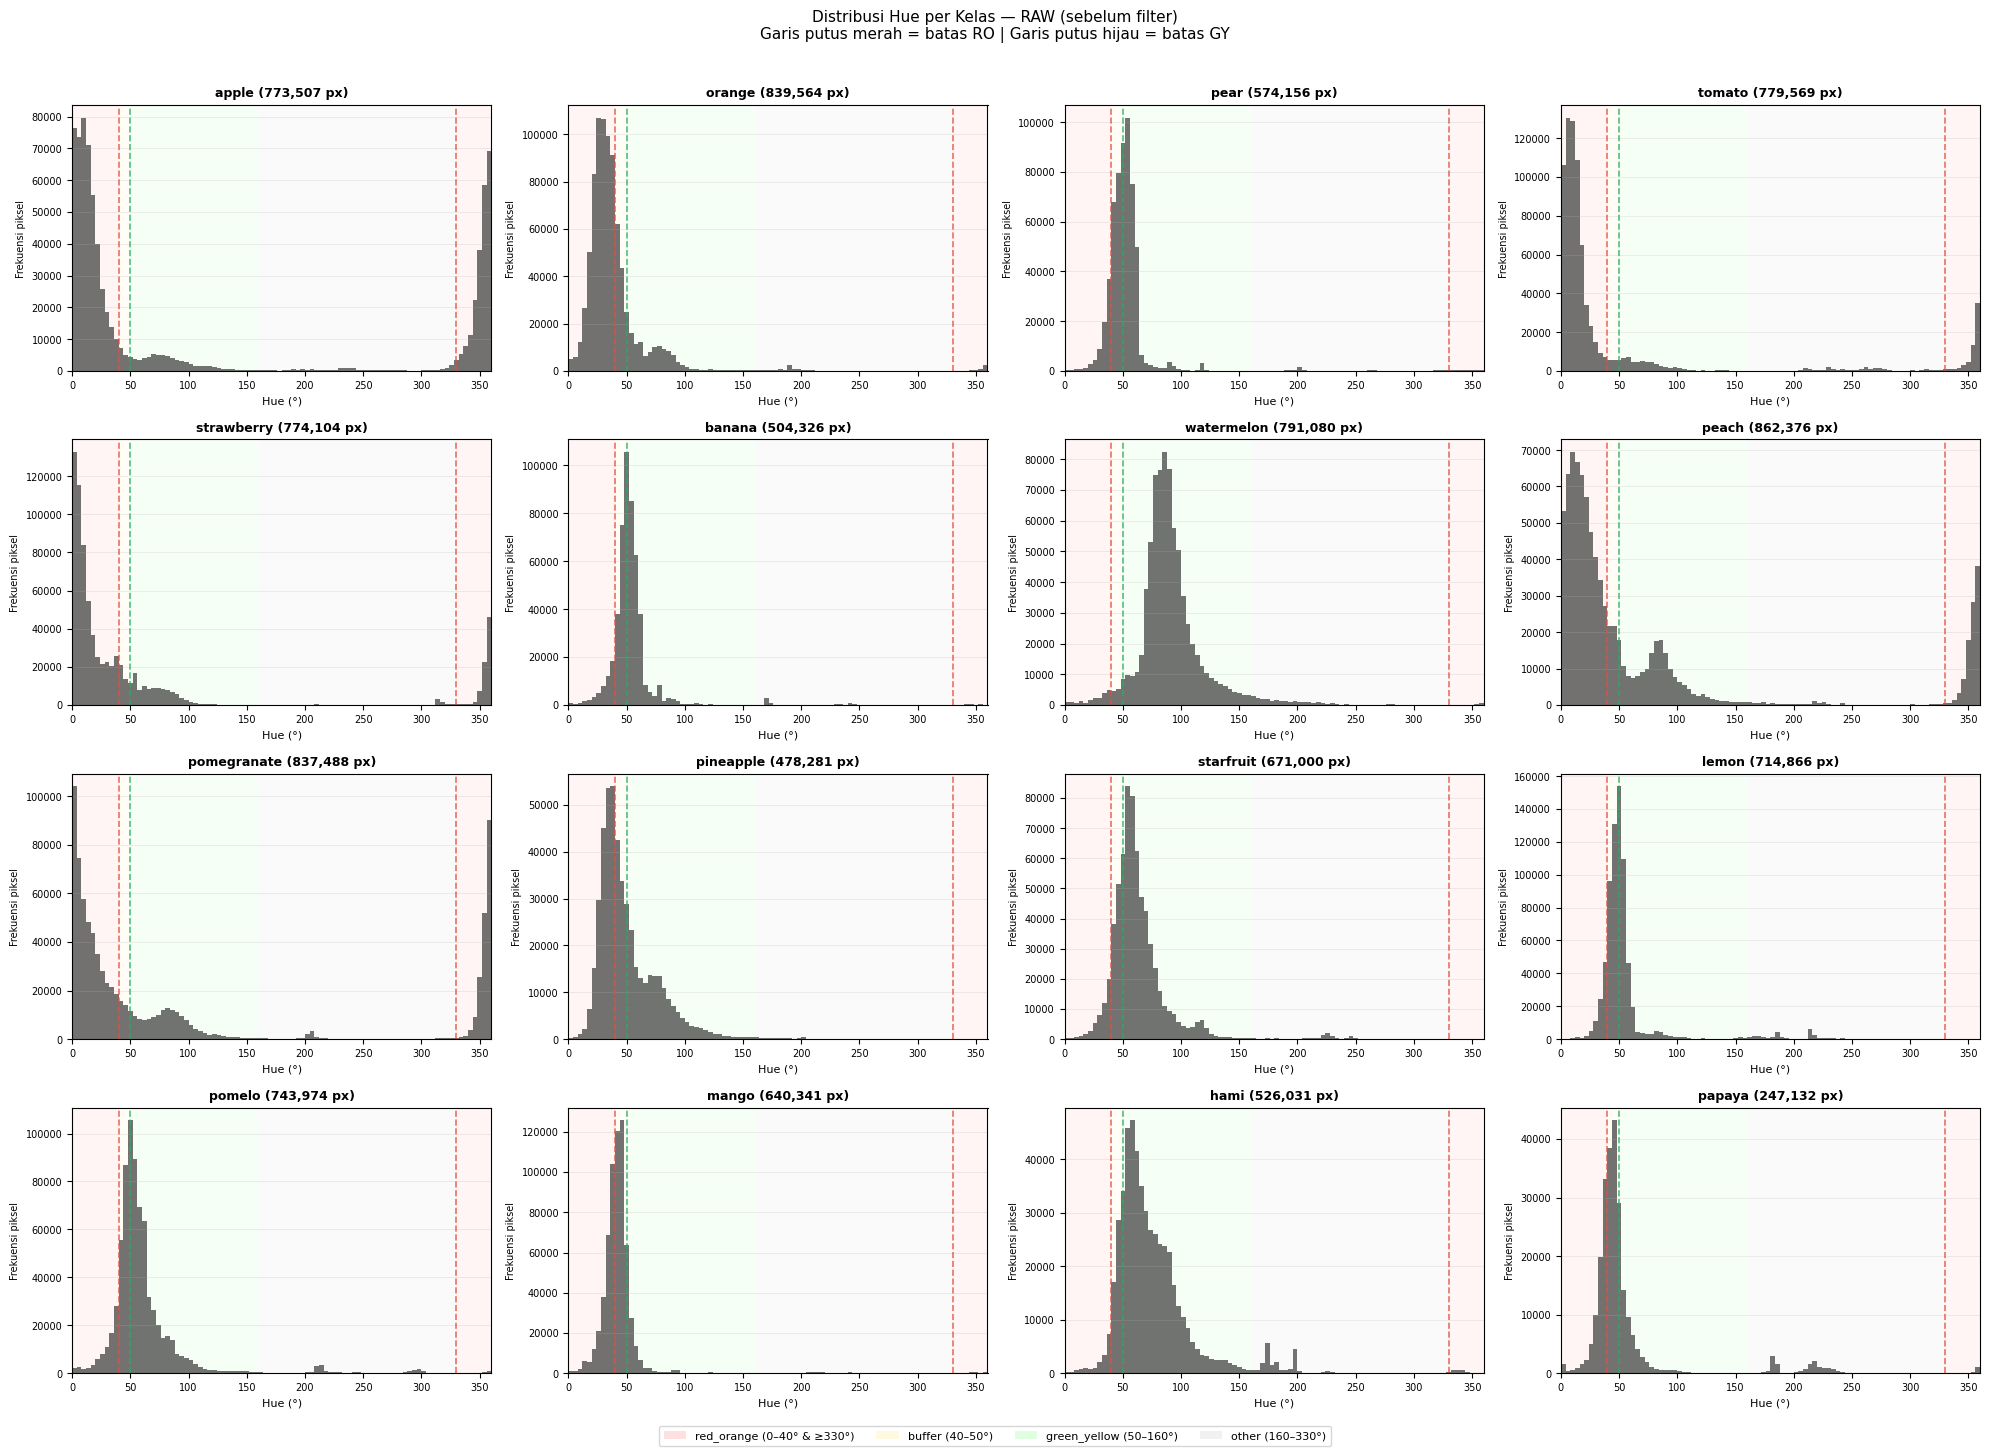

[2B] Selesai. Plot disimpan ke exports_dir/hue_distribution_per_class.png


In [6]:
# Histogram hue mentah per kelas (sebelum filter saturasi/dominance/boundary),
# untuk cek visual apakah hue dominan kelas sudah sesuai ekspektasi dan untuk mendeteksi kelas dengan distribusi hue ambigu

def sample_hues_from_class(
    folder_name: str,
    subset_dir : Path,
    max_images : int   = 100,
    sat_min    : float = 0.15,
) -> list[float]:
    """Sample hue 0-360 derajat dari piksel bersaturasi pada sejumlah gambar kelas."""
    class_dir = subset_dir / folder_name
    if not class_dir.exists():
        return []

    image_files = sorted(class_dir.glob("*.jpg")) + sorted(class_dir.glob("*.png"))
    if len(image_files) > max_images:
        rng = np.random.RandomState(RANDOM_SEED)
        image_files = list(rng.choice(image_files, max_images, replace=False))

    all_hues = []
    for img_path in image_files:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
        h_ch = img_hsv[:, :, 0].flatten() * 2.0          # 0-360
        s_ch = img_hsv[:, :, 1].flatten() / 255.0
        all_hues.extend(h_ch[s_ch >= sat_min].tolist())

    return all_hues


print("[2B] Sampling hue distribusi per kelas (train, sebelum filter)...")
print()

train_dir = SPLIT_DIR / "train"
hue_samples: dict[str, list[float]] = {}

for folder_name in kept_classes:
    hues = sample_hues_from_class(folder_name, train_dir)
    hue_samples[folder_name] = hues
    print(f"  {folder_name:<20} {len(hues):>8,} piksel valid dari train")

print()

n_cols  = 4
n_rows  = -(-len(kept_classes) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.5))
axes_flat = axes.flatten()

# Shading zona berdasarkan boundary operasional
ZONE_SHADES = [
    (0,                  HUE_RED_ORANGE_MAX,  "#FFCCCC", f"red_orange (0–{int(HUE_RED_ORANGE_MAX)})"),
    (HUE_RED_ORANGE_MAX, HUE_GREEN_YELLOW_MIN,"#FFF5CC", f"buffer ({int(HUE_RED_ORANGE_MAX)}–{int(HUE_GREEN_YELLOW_MIN)})"),
    (HUE_GREEN_YELLOW_MIN, 160,               "#CCFFCC", f"green_yellow ({int(HUE_GREEN_YELLOW_MIN)}–160)"),
    (160,                HUE_RED_ORANGE_MIN,  "#E8E8E8", "other (160–330)"),
    (HUE_RED_ORANGE_MIN, 360,                 "#FFCCCC", f"red_orange (≥{int(HUE_RED_ORANGE_MIN)})"),
]

for idx, folder_name in enumerate(kept_classes):
    ax    = axes_flat[idx]
    hues  = hue_samples.get(folder_name, [])

    for z_min, z_max, color, _ in ZONE_SHADES:
        ax.axvspan(z_min, z_max, alpha=0.18, color=color, lw=0)

    if hues:
        ax.hist(hues, bins=90, range=(0, 360), color="#444", alpha=0.75,
                edgecolor="none", linewidth=0)

    for vline, vc in [
        (HUE_RED_ORANGE_MAX,  "#E74C3C"),
        (HUE_GREEN_YELLOW_MIN,"#27AE60"),
        (HUE_RED_ORANGE_MIN,  "#E74C3C"),
    ]:
        ax.axvline(vline, color=vc, linestyle="--", lw=1.2, alpha=0.8)

    ax.set_title(f"{folder_name[3:]} ({len(hues):,} px)", fontsize=9, fontweight="bold")
    ax.set_xlabel("Hue (°)", fontsize=8)
    ax.set_ylabel("Frekuensi piksel", fontsize=7)
    ax.set_xlim(0, 360)
    ax.tick_params(labelsize=7)
    ax.grid(axis="y", alpha=0.3, lw=0.5)

for j in range(len(kept_classes), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Legend zona di luar plot
legend_elements = [
    Patch(facecolor="#FFCCCC", alpha=0.6, label=f"red_orange (0–{int(HUE_RED_ORANGE_MAX)}° & ≥{int(HUE_RED_ORANGE_MIN)}°)"),
    Patch(facecolor="#FFF5CC", alpha=0.6, label=f"buffer ({int(HUE_RED_ORANGE_MAX)}–{int(HUE_GREEN_YELLOW_MIN)}°)"),
    Patch(facecolor="#CCFFCC", alpha=0.6, label=f"green_yellow ({int(HUE_GREEN_YELLOW_MIN)}–160°)"),
    Patch(facecolor="#E8E8E8", alpha=0.6, label="other (160–330°)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           fontsize=8, bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.suptitle(
    "Distribusi Hue per Kelas — RAW (sebelum filter)\n"
    "Garis putus merah = batas RO | Garis putus hijau = batas GY",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / "hue_distribution_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("[2B] Selesai. Plot disimpan ke exports_dir/hue_distribution_per_class.png")


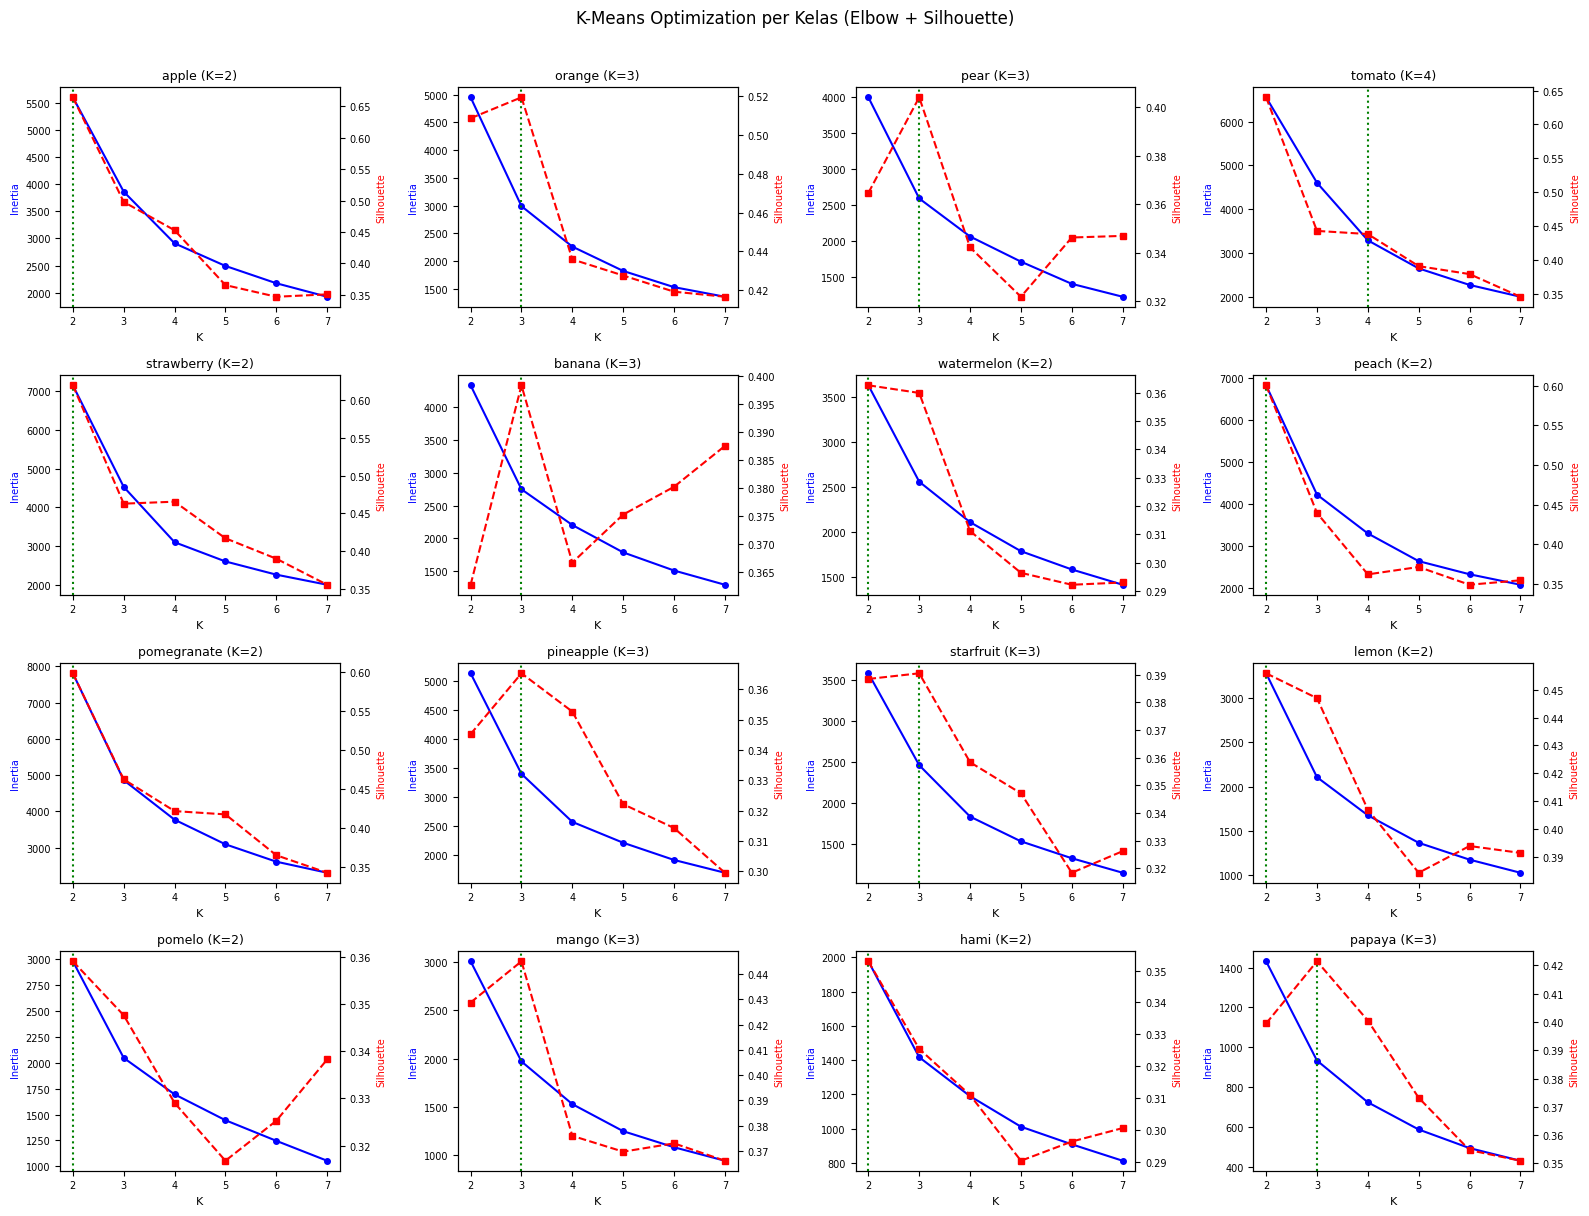

In [7]:
# Tahap 2B: Visualisasi elbow + silhouette per kelas
n_classes = len([k for k, v in k_results_per_class.items() if "error" not in v])
n_cols    = 4
n_rows    = -(-n_classes // n_cols)

if n_classes == 0:
    print("[2B] Tidak ada kelas yang berhasil dioptimasi — skip visualisasi.")
    print("     Cek apakah SPLIT_DIR sudah benar dan folder kelas ada.")
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
    axes_flat = axes.flatten() if n_rows > 1 else list(axes) if n_rows == 1 else [axes]

    plot_idx = 0
    for folder_name, result in k_results_per_class.items():
        if "error" in result:
            continue

        ax     = axes_flat[plot_idx]
        k_vals = result["k_values"]

        ax2 = ax.twinx()
        ax.plot(k_vals, result["inertias"],          "b-o",  ms=4, label="Inertia")
        ax2.plot(k_vals, result["silhouette_scores"], "r--s", ms=4, label="Silhouette")

        ax.axvline(result["optimal_k"], color="green", linestyle=":", lw=1.5,
                   label=f"K={result['optimal_k']}")

        ax.set_title(f"{folder_name[3:]} (K={result['optimal_k']})", fontsize=9)
        ax.set_xlabel("K", fontsize=8)
        ax.set_ylabel("Inertia", fontsize=7, color="blue")
        ax2.set_ylabel("Silhouette", fontsize=7, color="red")
        ax.set_xticks(k_vals)
        ax.tick_params(labelsize=7)
        ax2.tick_params(labelsize=7)

        plot_idx += 1

    # Sembunyikan axes yang tidak terpakai
    for j in range(plot_idx, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle("K-Means Optimization per Kelas (Elbow + Silhouette)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


## Tahap 2C — Ekstraksi & Filter Per Gambar

Setiap gambar diproses dengan:
1. Load & resize ke 224×224
2. Filter piksel berdasarkan saturasi (buang background netral)
3. K-Means clustering dengan K optimal kelas tersebut
4. Cek dominance ratio centroid terbesar
5. Classify hue dominan - `red_orange` / `green_yellow` / `other`
6. Gambar lolos - salin ke `fruit_filtered/subset/hue_range/`

K-optimization hanya dari train — K yang sama dipakai untuk val dan test.

In [8]:
def classify_hue_range(hue_360: float) -> str:
    """Klasifikasikan hue ke red_orange/green_yellow/other berdasarkan boundary global."""
    h = hue_360 % 360.0
    if h <= HUE_RED_ORANGE_MAX or h >= HUE_RED_ORANGE_MIN:
        return "red_orange"
    if HUE_GREEN_YELLOW_MIN < h <= HUE_GREEN_YELLOW_MAX:
        return "green_yellow"
    return "other"


def extract_single_image(
    image_path          : Path,
    optimal_k            : int,
    sat_threshold        : float = SATURATION_THRESHOLD,
    dominance_threshold  : float = DOMINANCE_THRESHOLD,
) -> dict:
    """Ekstrak warna dominan satu gambar via K-Means dan tentukan hue range-nya."""
    result_base = {"image_path": str(image_path), "status": "failed",
                   "hue_range": None, "reject_reason": None}

    # Step 1: Load & resize
    img = load_and_resize(image_path)
    if img is None:
        return {**result_base, "reject_reason": "load_failed"}

    # Step 2: Filter piksel berdasarkan saturasi
    valid_pixels = get_saturated_pixels(img, sat_threshold)
    if valid_pixels is None:
        return {**result_base, "reject_reason": "low_saturation"}

    # Step 3: K-Means clustering
    try:
        km     = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED, n_init=10)
        labels = km.fit_predict(valid_pixels)
    except Exception as e:
        return {**result_base, "reject_reason": f"kmeans_failed: {e}"}

    # Step 4: Hitung dominance ratio centroid terbesar
    counts          = np.bincount(labels)
    dominant_idx    = int(np.argmax(counts))
    dominance_ratio = float(counts[dominant_idx] / counts.sum())

    if dominance_ratio < dominance_threshold:
        return {**result_base, "reject_reason": "low_dominance", "dominance_ratio": dominance_ratio}

    # Step 5: Konversi hue centroid dominan ke derajat 0–360
    dominant_hue_360 = float(km.cluster_centers_[dominant_idx][0]) * 360.0

    # Step 6: Classify hue
    hue_range = classify_hue_range(dominant_hue_360)
    if hue_range == "other":
        return {**result_base, "reject_reason": "hue_other",
                "dominant_hue_360": round(dominant_hue_360, 2),
                "dominance_ratio": round(dominance_ratio, 4)}

    return {
        "image_path"      : str(image_path),
        "status"          : "success",
        "hue_range"       : hue_range,
        "dominant_hue_360": round(dominant_hue_360, 2),
        "dominance_ratio" : round(dominance_ratio, 4),
        "reject_reason"   : None,
    }


print("[2C] Fungsi ekstraksi siap.")
print(f"  Boundary hue red_orange  : h <= {HUE_RED_ORANGE_MAX}° atau h >= {HUE_RED_ORANGE_MIN}°")
print(f"  Boundary hue green_yellow: {HUE_GREEN_YELLOW_MIN}° < h <= {HUE_GREEN_YELLOW_MAX}°")
print(f"  Dominance threshold      : {DOMINANCE_THRESHOLD:.0%}")


[2C] Fungsi ekstraksi siap.
  Boundary hue red_orange  : h <= 40° atau h >= 330°
  Boundary hue green_yellow: 50° < h <= 160°
  Dominance threshold      : 45%


In [9]:
print("[TAHAP 2C] Menjalankan ekstraksi per gambar...")
print(f"  Total kelas: {len(kept_classes)}")
print(f"  Subset     : train, val, test")
print()

# Buat folder output
for subset in ["train", "val", "test"]:
    for hue_range in ["red_orange", "green_yellow"]:
        (FILTERED_DIR / subset / hue_range).mkdir(parents=True, exist_ok=True)

all_results : list[dict] = []
copy_errors : list[str]  = []

for folder_name in kept_classes:
    class_name = folder_name[3:]   # strip prefix angka (001, 002, dst)
    optimal_k  = k_results_per_class.get(folder_name, {}).get("optimal_k", 3)

    class_row = {"folder": folder_name, "k": optimal_k}

    for subset in ["train", "val", "test"]:
        src_dir = SPLIT_DIR / subset / folder_name
        if not src_dir.exists():
            continue

        image_paths = [
            f for f in src_dir.iterdir()
            if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
        ]

        n_success = 0
        n_failed  = 0

        for img_path in image_paths:
            result = extract_single_image(img_path, optimal_k)
            result["subset"]      = subset
            result["folder_name"] = folder_name
            result["class_name"]  = class_name
            all_results.append(result)

            if result["status"] == "success":
                dst_dir  = FILTERED_DIR / subset / result["hue_range"]
                dst_path = dst_dir / img_path.name
                try:
                    shutil.copy2(img_path, dst_path)
                    n_success += 1
                except Exception as e:
                    copy_errors.append(f"{subset}/{folder_name}/{img_path.name}: {e}")
                    n_failed += 1
            else:
                n_failed += 1

        class_row[f"{subset}_ok"]   = n_success
        class_row[f"{subset}_fail"] = n_failed

    # Print progress per kelas
    tr_ok = class_row.get("train_ok", 0)
    tr_fl = class_row.get("train_fail", 0)
    va_ok = class_row.get("val_ok", 0)
    te_ok = class_row.get("test_ok", 0)
    rej_rate = class_row.get("train_fail", 0) / max(tr_ok + tr_fl, 1)
    print(
        f"  {folder_name:<20}  K={optimal_k}  "
        f"train={tr_ok:>3}✓{tr_fl:>3}✗  "
        f"val={va_ok:>3}✓  test={te_ok:>3}✓  "
        f"rej={rej_rate:.0%}"
    )

df_results = pd.DataFrame(all_results)

print()
print(f"[2C] Selesai. Total gambar diproses: {len(all_results):,}")
if copy_errors:
    print(f"  ⚠ Copy errors: {len(copy_errors)}")
    for err in copy_errors[:5]:
        print(f"    - {err}")


[TAHAP 2C] Menjalankan ekstraksi per gambar...
  Total kelas: 16
  Subset     : train, val, test

  001apple              K=2  train=323✓  9✗  val= 30✓  test= 38✓  rej=3%
  002orange             K=3  train=293✓ 88✗  val= 22✓  test= 42✓  rej=23%
  003pear               K=3  train= 80✓125✗  val= 12✓  test= 18✓  rej=61%
  004tomato             K=4  train=250✓107✗  val= 22✓  test= 22✓  rej=30%
  005strawberry         K=2  train=373✓ 12✗  val= 29✓  test= 45✓  rej=3%
  006banana             K=3  train=139✓159✗  val= 16✓  test= 15✓  rej=53%
  007watermelon         K=2  train=181✓  0✗  val= 30✓  test= 41✓  rej=0%
  009peach              K=2  train=223✓ 19✗  val= 27✓  test= 32✓  rej=8%
  010pomegranate        K=2  train=150✓ 18✗  val= 29✓  test= 11✓  rej=11%
  011pineapple          K=3  train= 42✓110✗  val=  9✓  test= 10✓  rej=72%
  012starfruit          K=3  train= 79✓ 43✗  val= 12✓  test= 20✓  rej=35%
  014lemon              K=2  train= 37✓ 73✗  val=  7✓  test= 15✓  rej=66%
  015pomelo       

## Tahap 2D — Analisis Hasil

Analisis distribusi hue range dan rejection rate per kelas untuk memutuskan
perlu tidaknya capped undersampling sebelum lanjut ke NB03.


In [10]:
print("[TAHAP 2D] Analisis distribusi hasil ekstraksi...")
print()

df_success = df_results[df_results["status"] == "success"].copy()
df_failed  = df_results[df_results["status"] == "failed"].copy()

# Distribusi hue range dihitung dari train saja — dasar keputusan undersampling
df_train_success = df_success[df_success["subset"] == "train"]

print("  Distribusi hue range per kelas (train):")
print(f"  {'Kelas':<20} {'red_orange':>11} {'green_yellow':>13} {'Total':>7} {'Dominant':>10}")
print(f"  {'-'*65}")

hue_summary: list[dict] = []
for folder_name in kept_classes:
    df_cls = df_train_success[df_train_success["folder_name"] == folder_name]
    n_ro   = (df_cls["hue_range"] == "red_orange").sum()
    n_gy   = (df_cls["hue_range"] == "green_yellow").sum()
    total  = n_ro + n_gy
    dominant = "red_orange" if n_ro >= n_gy else "green_yellow"

    hue_summary.append({
        "folder_name"  : folder_name,
        "class_name"   : folder_name[3:],
        "red_orange"   : int(n_ro),
        "green_yellow" : int(n_gy),
        "total_success": int(total),
        "dominant_hue" : dominant,
    })
    print(f"  {folder_name:<20} {n_ro:>11,} {n_gy:>13,} {total:>7,}  {dominant}")

df_hue_summary = pd.DataFrame(hue_summary)

# Total per hue range
total_ro = df_hue_summary["red_orange"].sum()
total_gy = df_hue_summary["green_yellow"].sum()
ratio    = max(total_ro, total_gy) / max(min(total_ro, total_gy), 1)

print(f"  {'-'*65}")
print(f"  {'TOTAL':<20} {total_ro:>11,} {total_gy:>13,}")
print()
print(f"  red_orange   : {total_ro:,}")
print(f"  green_yellow : {total_gy:,}")
print(f"  Imbalance ratio: {ratio:.2f}x")

if ratio > 2.0:
    print(f"Ratio > 2.0 — pertimbangkan capped undersampling di langkah berikutnya")
else:
    print(f"Ratio <= 2.0 — distribusi cukup seimbang")


[TAHAP 2D] Analisis distribusi hasil ekstraksi...

  Distribusi hue range per kelas (train):
  Kelas                 red_orange  green_yellow   Total   Dominant
  -----------------------------------------------------------------
  001apple                     323             0     323  red_orange
  002orange                    293             0     293  red_orange
  003pear                        2            78      80  green_yellow
  004tomato                    250             0     250  red_orange
  005strawberry                373             0     373  red_orange
  006banana                      3           136     139  green_yellow
  007watermelon                  0           181     181  green_yellow
  009peach                     223             0     223  red_orange
  010pomegranate               148             2     150  red_orange
  011pineapple                  40             2      42  red_orange
  012starfruit                   7            72      79  green_yellow
  01

In [11]:
print("  Rejection analysis per kelas (train):")
print(f"  {'Kelas':<20} {'Total':>7} {'Lolos':>7} {'Reject':>7} {'Rej%':>7} {'Top Reason'}")
print(f"  {'-'*70}")

df_train_all = df_results[df_results["subset"] == "train"]

reject_summary: list[dict] = []
for folder_name in kept_classes:
    df_cls    = df_train_all[df_train_all["folder_name"] == folder_name]
    n_total   = len(df_cls)
    n_success = (df_cls["status"] == "success").sum()
    n_failed  = (df_cls["status"] == "failed").sum()
    rej_rate  = n_failed / n_total if n_total > 0 else 0

    top_reason = ""
    if n_failed > 0:
        top_reason = df_cls[df_cls["status"] == "failed"]["reject_reason"].value_counts().index[0]

    reject_summary.append({
        "folder_name": folder_name,
        "total"      : int(n_total),
        "success"    : int(n_success),
        "failed"     : int(n_failed),
        "rej_rate"   : round(rej_rate, 4),
        "top_reason" : top_reason,
    })
    print(
        f"  {folder_name:<20} {n_total:>7,} {n_success:>7,} "
        f"{n_failed:>7,} {rej_rate:>6.1%}  {top_reason}"
    )

df_reject = pd.DataFrame(reject_summary)

print()
total_train = df_train_all.shape[0]
total_ok    = (df_train_all["status"] == "success").sum()
total_fail  = (df_train_all["status"] == "failed").sum()
print(f"  Overall train rejection rate: {total_fail/total_train:.1%} "
      f"({total_fail:,} dari {total_train:,})")
print()

print("Breakdown alasan reject (train):")
reason_counts = df_train_all[df_train_all["status"]=="failed"]["reject_reason"].value_counts()
for reason, count in reason_counts.items():
    pct = count / total_fail * 100 if total_fail > 0 else 0
    print(f"    {reason:<25}: {count:>5,} ({pct:.1f}%)")


  Rejection analysis per kelas (train):
  Kelas                  Total   Lolos  Reject    Rej% Top Reason
  ----------------------------------------------------------------------
  001apple                 332     323       9   2.7%  hue_other
  002orange                381     293      88  23.1%  hue_other
  003pear                  205      80     125  61.0%  hue_other
  004tomato                357     250     107  30.0%  low_dominance
  005strawberry            385     373      12   3.1%  hue_other
  006banana                298     139     159  53.4%  hue_other
  007watermelon            181     181       0   0.0%  
  009peach                 242     223      19   7.9%  hue_other
  010pomegranate           168     150      18  10.7%  hue_other
  011pineapple             152      42     110  72.4%  low_dominance
  012starfruit             122      79      43  35.2%  low_dominance
  014lemon                 110      37      73  66.4%  hue_other
  015pomelo                 89      55

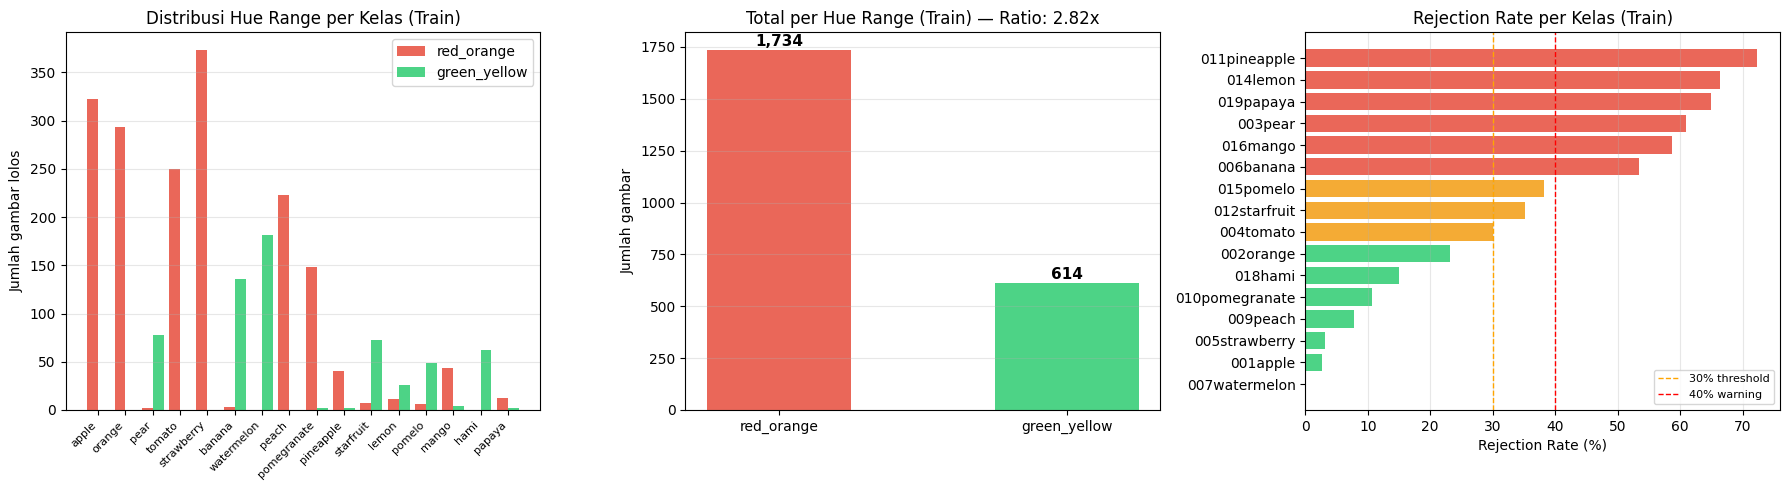

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: distribusi hue range per kelas (train)
ax = axes[0]
x  = range(len(df_hue_summary))
w  = 0.4
ax.bar([i - w/2 for i in x], df_hue_summary["red_orange"],
       width=w, label="red_orange",   color="#E74C3C", alpha=0.85)
ax.bar([i + w/2 for i in x], df_hue_summary["green_yellow"],
       width=w, label="green_yellow", color="#2ECC71", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(df_hue_summary["class_name"], rotation=45, ha="right", fontsize=8)
ax.set_title("Distribusi Hue Range per Kelas (Train)")
ax.set_ylabel("Jumlah gambar lolos")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Plot 2: total per hue range (train)
ax = axes[1]
totals = [total_ro, total_gy]
colors = ["#E74C3C", "#2ECC71"]
bars   = ax.bar(["red_orange", "green_yellow"], totals, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title(f"Total per Hue Range (Train) — Ratio: {ratio:.2f}x")
ax.set_ylabel("Jumlah gambar")
ax.grid(axis="y", alpha=0.3)

# Plot 3: rejection rate per kelas
ax = axes[2]
df_rej_sorted = df_reject.sort_values("rej_rate", ascending=True)
colors_rej    = ["#E74C3C" if r > 0.4 else "#F39C12" if r > 0.25 else "#2ECC71"
                 for r in df_rej_sorted["rej_rate"]]
ax.barh(df_rej_sorted["folder_name"], df_rej_sorted["rej_rate"] * 100,
        color=colors_rej, alpha=0.85)
ax.axvline(30, color="orange", linestyle="--", lw=1, label="30% threshold")
ax.axvline(40, color="red",    linestyle="--", lw=1, label="40% warning")
ax.set_xlabel("Rejection Rate (%)")
ax.set_title("Rejection Rate per Kelas (Train)")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## Tahap 2E — Ekspor Hasil & Summary

Ekspor hasil ekstraksi dan metadata pipeline untuk referensi NB03 dan sebagai
dasar keputusan capped undersampling.


In [13]:
print("[TAHAP 2E] Verifikasi struktur fruit_filtered/...")
print()

verify_rows: list[dict] = []
for subset in ["train", "val", "test"]:
    for hue_range in ["red_orange", "green_yellow"]:
        folder = FILTERED_DIR / subset / hue_range
        if folder.exists():
            count = sum(
                1 for f in folder.iterdir()
                if f.suffix.lower() in VALID_EXTENSIONS
            )
            verify_rows.append({"subset": subset, "hue_range": hue_range, "count": count})
        else:
            verify_rows.append({"subset": subset, "hue_range": hue_range, "count": 0})

df_verify = pd.DataFrame(verify_rows)
df_vpivot = df_verify.pivot(
    index="hue_range", columns="subset", values="count"
).fillna(0).astype(int)
df_vpivot["total"] = df_vpivot.sum(axis=1)

print(df_vpivot.to_string())

grand_total = int(df_vpivot["total"].sum())
print(f"\n  Grand total: {grand_total:,} gambar di fruit_filtered/")

# Cek imbalance per subset
print()
for subset in ["train", "val", "test"]:
    if subset not in df_vpivot.columns:
        continue
    ro  = int(df_vpivot.loc["red_orange",   subset]) if "red_orange"   in df_vpivot.index else 0
    gy  = int(df_vpivot.loc["green_yellow", subset]) if "green_yellow" in df_vpivot.index else 0
    rat = max(ro, gy) / max(min(ro, gy), 1)
    flag = "pertimbangkan undersampling" if rat > 2.0 else "OK"
    print(f"  {subset:<6}: red_orange={ro:>4,}  green_yellow={gy:>4,}  ratio={rat:.2f}x  [{flag}]")


[TAHAP 2E] Verifikasi struktur fruit_filtered/...

subset        test  train  val  total
hue_range                            
green_yellow   148    614   93    855
red_orange     224   1734  180   2138

  Grand total: 2,993 gambar di fruit_filtered/

  train : red_orange=1,734  green_yellow= 614  ratio=2.82x  [pertimbangkan undersampling]
  val   : red_orange= 180  green_yellow=  93  ratio=1.94x  [OK]
  test  : red_orange= 224  green_yellow= 148  ratio=1.51x  [OK]


In [14]:
# Ekspor hasil per gambar
export_cols = ["folder_name", "class_name", "subset", "status",
               "hue_range", "dominant_hue_360", "dominance_ratio", "reject_reason"]
df_export = df_results[[c for c in export_cols if c in df_results.columns]].copy()
df_export.to_json(
    EXPORTS_DIR / "extraction_results.json",
    orient="records", indent=2, force_ascii=False
)

# Ekspor K per kelas
k_export = {
    folder: {"optimal_k": res.get("optimal_k"), "elbow_k": res.get("elbow_k"),
             "best_sil_k": res.get("best_sil_k"), "n_samples_used": res.get("n_samples_used")}
    for folder, res in k_results_per_class.items()
}
with open(EXPORTS_DIR / "k_per_class.json", "w", encoding="utf-8") as f:
    json.dump(k_export, f, indent=2, ensure_ascii=False)

# Ekspor hue distribution summary
def _to_serializable(obj):
    """Konversi rekursif tipe numpy/pandas ke tipe Python native untuk JSON."""
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, dict):           return {k: _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):           return [_to_serializable(v) for v in obj]
    return obj


hue_dist_export = {
    "timestamp"            : datetime.datetime.now().isoformat(),
    "saturation_threshold" : SATURATION_THRESHOLD,
    "dominance_threshold"  : DOMINANCE_THRESHOLD,
    "hue_boundary"         : {
        "red_orange_max"   : HUE_RED_ORANGE_MAX,
        "red_orange_min"   : HUE_RED_ORANGE_MIN,
        "green_yellow_min" : HUE_GREEN_YELLOW_MIN,
        "green_yellow_max" : HUE_GREEN_YELLOW_MAX,
    },
    "train_distribution"   : {
        "red_orange"  : int(total_ro),
        "green_yellow": int(total_gy),
        "imbalance_ratio": round(ratio, 3),
    },
    "per_class_hue"        : df_hue_summary.to_dict(orient="records"),
    "rejection_summary"    : df_reject.to_dict(orient="records"),
    "overall_rejection_rate": round(total_fail / total_train, 4),
}

with open(EXPORTS_DIR / "extraction_summary.json", "w", encoding="utf-8") as f:
    json.dump(_to_serializable(hue_dist_export), f, indent=2, ensure_ascii=False)

print("[TAHAP 2E] Ekspor selesai.")
print(f"  extraction_results.json  → {len(df_export):,} baris")
print(f"  k_per_class.json         → {len(k_export)} kelas")
print(f"  extraction_summary.json  → distribusi & rejection summary")
print()
print("  RINGKASAN PIPELINE NB02")
print(f"  Total gambar diproses    : {len(df_results):,}")
print(f"  Total lolos              : {(df_results['status']=='success').sum():,}")
print(f"  Total rejected           : {(df_results['status']=='failed').sum():,}")
print(f"  Overall rejection rate   : {total_fail/total_train:.1%} (train)")
print()
print(f"  fruit_filtered/train:")
print(f"    red_orange   : {total_ro:,}")
print(f"    green_yellow : {total_gy:,}")
print(f"    imbalance    : {ratio:.2f}x")
print()
if ratio > 2.0:
    print(" Imbalance > 2.0x — disarankan capped undersampling sebelum NB03")
    print("    Jalankan cell undersampling di bawah jika diperlukan.")
else:
    print("  Distribusi cukup seimbang — lanjut ke NB03.")


[TAHAP 2E] Ekspor selesai.
  extraction_results.json  → 4,232 baris
  k_per_class.json         → 16 kelas
  extraction_summary.json  → distribusi & rejection summary

  RINGKASAN PIPELINE NB02
  Total gambar diproses    : 4,232
  Total lolos              : 2,993
  Total rejected           : 1,239
  Overall rejection rate   : 27.7% (train)

  fruit_filtered/train:
    red_orange   : 1,734
    green_yellow : 614
    imbalance    : 2.82x

 Imbalance > 2.0x — disarankan capped undersampling sebelum NB03
    Jalankan cell undersampling di bawah jika diperlukan.


## Tahap 2F — Capped Undersampling

Jalankan cell ini jika imbalance ratio train > 2.0x dari hasil Tahap 2E.
Undersampling diterapkan pada train — val dan test dibiarkan apa adanya
untuk menjaga representasi distribusi asli dataset.

In [15]:
if ratio <= 2.0:
    print(f"[UNDERSAMPLING] Tidak diperlukan — ratio {ratio:.2f}x <= 2.0x")
else:
    print(f"[UNDERSAMPLING] Ratio {ratio:.2f}x > 2.0x — menjalankan capped undersampling...")
    print(f"  Cap target: {min(total_ro, total_gy):,} gambar per hue range (train)")
    print()

    cap_target = int(min(total_ro, total_gy))
    rng        = random.Random(RANDOM_SEED)

    for hue_range in ["red_orange", "green_yellow"]:
        folder = FILTERED_DIR / "train" / hue_range
        all_files = [
            f for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
        ]
        current = len(all_files)

        if current <= cap_target:
            print(f"  {hue_range:<15}: {current:,} gambar — sudah <= cap, tidak diubah")
            continue

        # Pilih gambar yang akan dihapus secara acak
        n_remove = current - cap_target
        rng.shuffle(all_files)
        to_remove = all_files[:n_remove]

        for f in to_remove:
            f.unlink()

        print(f"  {hue_range:<15}: {current:,} → {cap_target:,} "
              f"(hapus {n_remove:,} gambar)")

    print()
    print("  Verifikasi setelah undersampling:")
    for hue_range in ["red_orange", "green_yellow"]:
        folder = FILTERED_DIR / "train" / hue_range
        count  = sum(1 for f in folder.iterdir()
                     if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS)
        print(f"    train/{hue_range}: {count:,} gambar")

    hue_dist_export["undersampling_applied"] = True
    hue_dist_export["cap_target"]            = cap_target
    with open(EXPORTS_DIR / "extraction_summary.json", "w", encoding="utf-8") as f:
        json.dump(_to_serializable(hue_dist_export), f, indent=2, ensure_ascii=False)
    print()
    print("  extraction_summary.json diperbarui.")
    print("[UNDERSAMPLING] Selesai. Lanjut ke NB03.")


[UNDERSAMPLING] Ratio 2.82x > 2.0x — menjalankan capped undersampling...
  Cap target: 614 gambar per hue range (train)

  red_orange     : 1,734 → 614 (hapus 1,120 gambar)
  green_yellow   : 614 gambar — sudah <= cap, tidak diubah

  Verifikasi setelah undersampling:
    train/red_orange: 614 gambar
    train/green_yellow: 614 gambar

  extraction_summary.json diperbarui.
[UNDERSAMPLING] Selesai. Lanjut ke NB03.
